## <strong>7. 탐색적 데이터 분석</strong>

### **데이터 전처리**

#### **1. 라이브러리 임포트 및 데이터 로드**

In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install missingno
!pip install pyqt5
!pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# # 시각화 설정 (인터랙티브 창으로 시각화)
# %matplotlib qt5
# %config InlineBackend.figure_format = 'svg'
# plt.ion()

In [2]:
# 데이터 로드
path = "./data/"  # 데이터셋 폴더
filename = "moldset_labeled_cn7_missing.csv"
df = pd.read_csv(path + filename)

# 데이터 상위 5개 확인
df.head()

,Unnamed: 0,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,0,1.679123,1.491397,NaN,0.361047,0.97858,-0.711164,1.532018,NaN,...,-0.533773,0.729073,-1.598068,-0.672350,-1.536620,0.008133,-1.352970,-1.780463,1.023094,1.287574
1,1,0,2.080358,1.894372,NaN,1.886261,0.97858,-0.711164,1.471608,0.0,...,-0.533773,NaN,0.622557,0.914107,0.504051,-0.915098,NaN,-0.874018,1.023094,1.337339
2,2,0,2.080358,1.894372,-0.5271,1.886261,0.97858,-0.711164,1.471608,0.0,...,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339
3,3,0,1.679123,1.894372,-0.5271,1.377857,0.97858,1.202502,1.471608,NaN,...,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339
4,4,0,1.679123,1.894372,-0.5271,1.377857,0.97858,1.202502,1.471608,0.0,...,-0.533773,NaN,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339


In [3]:
# 데이터 정보 확인 (데이터 타입, 결측치 유무 1차 확인)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1211 entries, 0 to 1210
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                1211 non-null   int64  
 1   PassOrFail                1211 non-null   int64  
 2   Injection_Time            1211 non-null   float64
 3   Filling_Time              1211 non-null   float64
 4   Plasticizing_Time         965 non-null    float64
 5   Cycle_Time                1211 non-null   float64
 6   Clamp_Close_Time          1211 non-null   float64
 7   Cushion_Position          1211 non-null   float64
 8   Plasticizing_Position     1211 non-null   float64
 9   Clamp_Open_Position       1024 non-null   float64
 10  Max_Injection_Speed       1211 non-null   float64
 11  Max_Screw_RPM             1108 non-null   float64
 12  Average_Screw_RPM         1211 non-null   float64
 13  Max_Injection_Pressure    1211 non-null   float64
 14  Max_Switch_Over_Pre

#### **2. 기초 통계량 및 타겟 분포 확인 (EDA)**

In [4]:
# 기초 통계량 확인
display(df.describe())

,Unnamed: 0,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
count,1211.000000,1211.000000,1.211000e+03,1.211000e+03,965.000000,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1024.0,...,1.211000e+03,996.000000,1137.000000,1.211000e+03,1.211000e+03,1.211000e+03,1095.000000,1.211000e+03,1.211000e+03,1.211000e+03
mean,605.000000,0.014038,-2.957172e-14,-5.351073e-15,0.010671,5.069438e-14,-1.574811e-14,4.630532e-12,-3.628403e-14,0.0,...,-3.708200e-15,0.016487,-0.009757,8.745367e-15,2.114319e-14,5.257195e-15,0.001517,-2.675537e-15,-8.214367e-16,-1.642873e-16
std,349.729896,0.117696,1.000413e+00,1.000413e+00,1.103891,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,0.0,...,1.000413e+00,1.008772,1.004835,1.000413e+00,1.000413e+00,1.000413e+00,0.998437,1.000413e+00,1.000413e+00,1.000413e+00
min,0.000000,0.000000,-7.549091e+00,-7.776799e+00,-0.723425,-3.706092e+00,-9.024657e-01,-2.613163e+00,-2.876962e+00,0.0,...,-6.631852e+00,-2.635662,-2.985979,-2.893331e+00,-2.046826e+00,-4.607976e+00,-2.719099,-2.082616e+00,-1.909796e+00,-1.648589e+00
25%,302.500000,0.000000,-7.282486e-01,-5.234162e-01,-0.379849,-6.557617e-01,-9.024657e-01,-7.111644e-01,-7.026540e-01,0.0,...,-5.337734e-01,-0.616835,-0.765355,-3.550389e-01,-8.989006e-01,-6.073388e-01,-0.897571,-8.740180e-01,-7.652542e-01,-7.528108e-01
50%,605.000000,0.000000,-3.270136e-01,-1.204612e-01,-0.036274,3.610475e-01,-9.024657e-01,-7.111644e-01,-6.422898e-01,0.0,...,2.284901e-01,0.056153,0.067358,-3.772821e-02,-6.117000e-03,8.132912e-03,0.013158,-1.689960e-01,9.315350e-02,-1.556248e-01
75%,907.500000,0.000000,8.766531e-01,6.854681e-01,0.209135,3.610475e-01,9.785804e-01,1.202502e+00,1.471608e+00,0.0,...,6.096146e-01,0.729073,0.622557,5.968932e-01,8.867055e-01,6.236047e-01,0.468557,7.374564e-01,1.094628e+00,1.287574e+00
max,1210.000000,1.000000,2.080358e+00,2.297327e+00,20.038456,1.256247e+01,2.859537e+00,6.943503e+00,1.592429e+00,0.0,...,1.753017e+00,3.196558,3.398379,3.135185e+00,2.544760e+00,3.393298e+00,2.745415,2.550354e+00,1.380764e+00,1.436870e+00


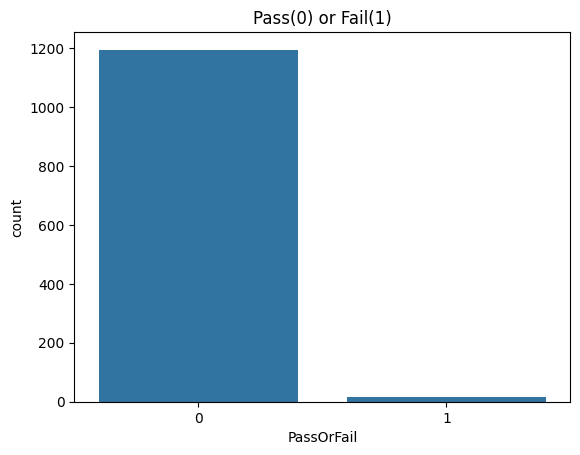

In [5]:
# 타겟 데이터(PassOrFail) 분포 시각화
# 가이드북에 따라 불량(Y/N) 비율 확인
sns.countplot(x='PassOrFail', data=df)
plt.title('Pass(0) or Fail(1)') #Fail이 긍정, Pass가 부정.
plt.show()

In [6]:
df['PassOrFail']

0       0
1       0
2       0
3       0
4       0
       ..
1206    0
1207    0
1208    0
1209    0
1210    0
Name: PassOrFail, Length: 1211, dtype: int64

In [7]:
# 양품 여부에 대한 Boolean array 생성
df['PassOrFail'] == 0

0       True
1       True
2       True
3       True
4       True
        ... 
1206    True
1207    True
1208    True
1209    True
1210    True
Name: PassOrFail, Length: 1211, dtype: bool

In [8]:
# 불량률 계산
fail_cnt = len(df[df['PassOrFail'] == 1])  # 불량(Fail) 개수
total_cnt = len(df)

print(f'Defect rate: {fail_cnt} (# of failures) / {total_cnt} (# of total) = {(fail_cnt / total_cnt) * 100 :.1f}%')

Defect rate: 17 (# of failures) / 1211 (# of total) = 1.4%


#### **3. 결측치 확인 및 시각화**

In [9]:
df.isnull().sum()

Unnamed: 0                    0
PassOrFail                    0
Injection_Time                0
Filling_Time                  0
Plasticizing_Time           246
Cycle_Time                    0
Clamp_Close_Time              0
Cushion_Position              0
Plasticizing_Position         0
Clamp_Open_Position         187
Max_Injection_Speed           0
Max_Screw_RPM               103
Average_Screw_RPM             0
Max_Injection_Pressure        0
Max_Switch_Over_Pressure      0
Max_Back_Pressure             0
Average_Back_Pressure         0
Barrel_Temperature_1        215
Barrel_Temperature_2         74
Barrel_Temperature_3          0
Barrel_Temperature_4          0
Barrel_Temperature_5          0
Barrel_Temperature_6        116
Hopper_Temperature            0
Mold_Temperature_3            0
Mold_Temperature_4            0
dtype: int64

In [10]:
# 결측치 개수와 비율 확인
null_cnt = df.isnull().sum()
null_ratio = (df.isnull().sum() / len(df)) * 100

# 결측치가 있는 컬럼만 필터링해서 출력
missing_df = pd.DataFrame({'Null Count': null_cnt, 'Null Ratio(%)': null_ratio})
display(missing_df[missing_df['Null Count'] > 0].sort_values(by='Null Ratio(%)', ascending=False))

,Null Count,Null Ratio(%)
Plasticizing_Time,246,20.313790
Barrel_Temperature_1,215,17.753922
Clamp_Open_Position,187,15.441784
Barrel_Temperature_6,116,9.578860
Max_Screw_RPM,103,8.505367
Barrel_Temperature_2,74,6.110652


<Figure size 1200x600 with 0 Axes>

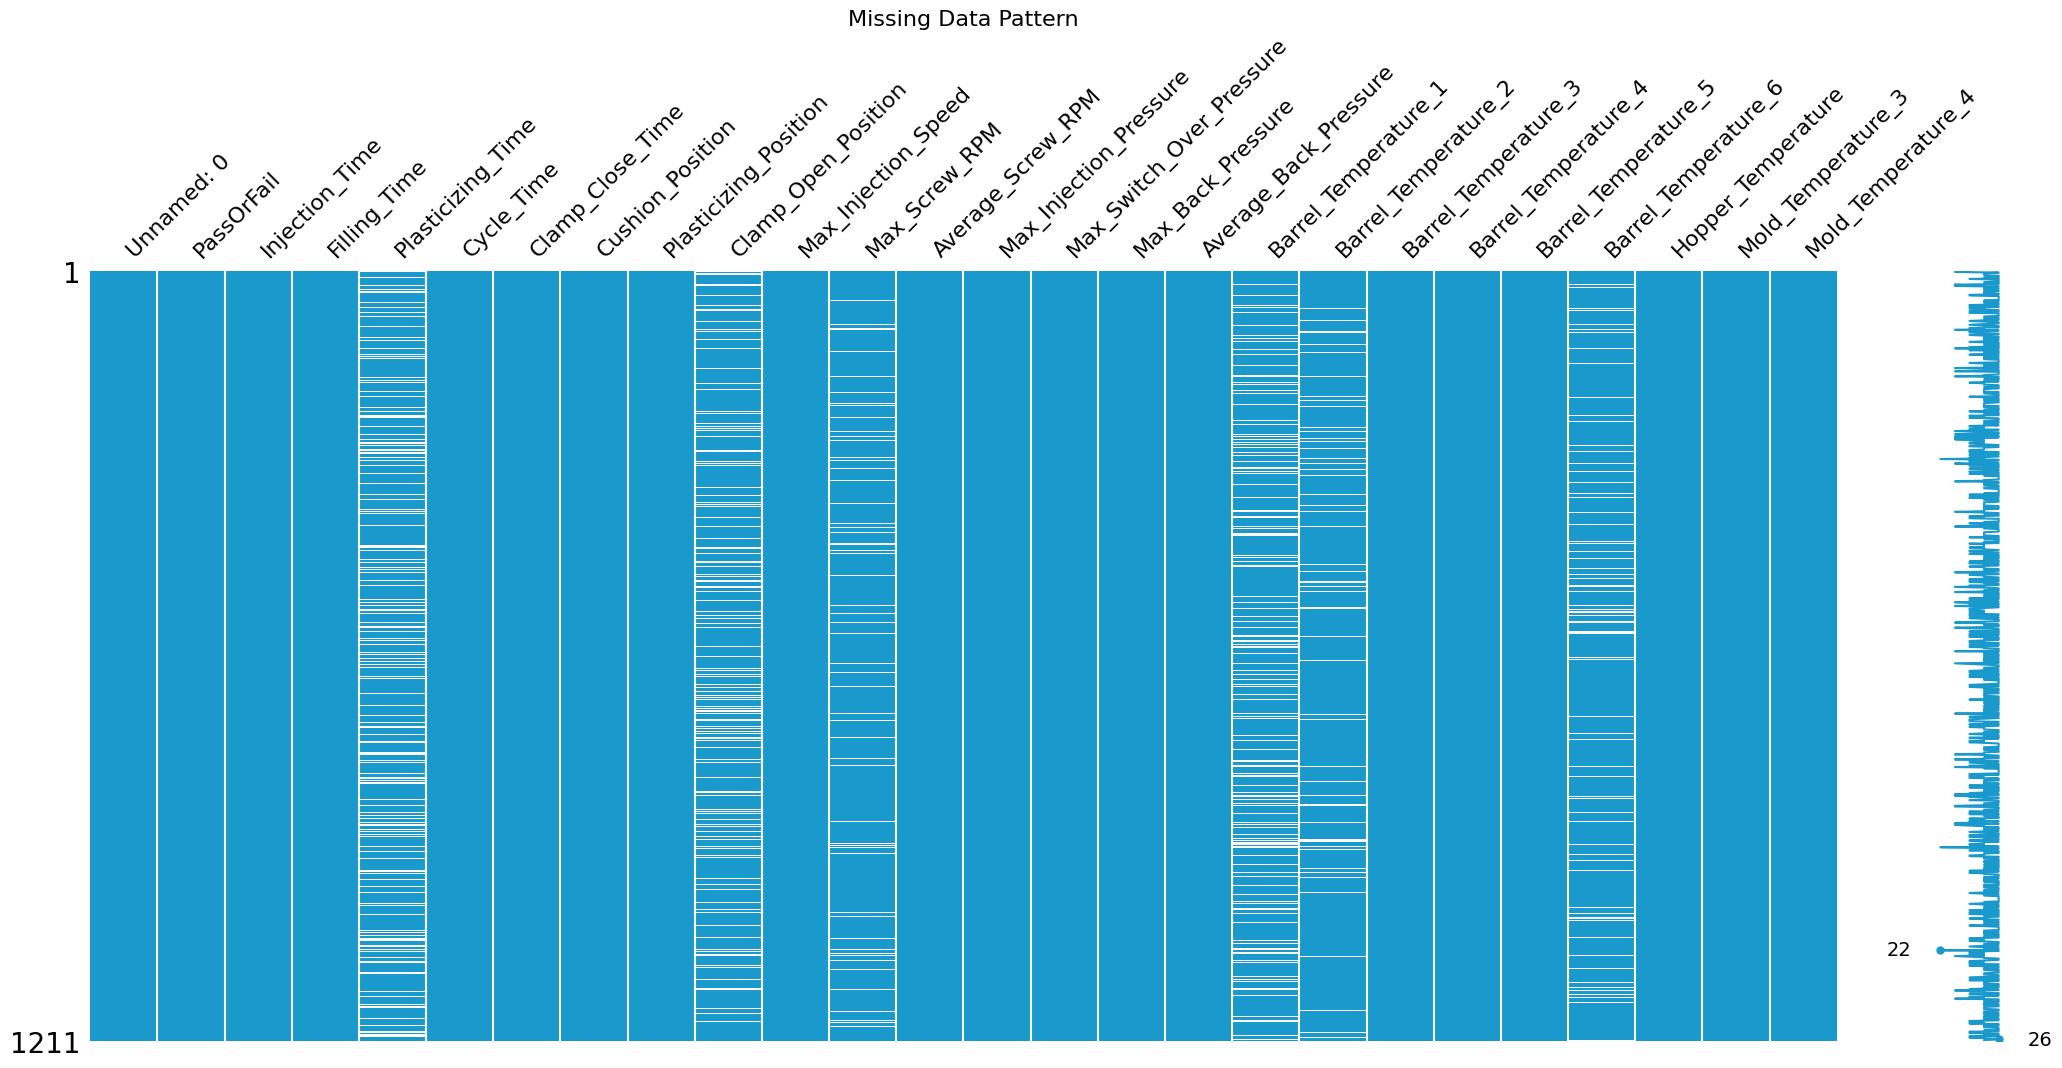

In [11]:
# msno.matrix: 결측치 위치를 시각적으로 표현
# 데이터가 시계열 순서대로 정렬되어 있다면, 특정 시간대에 결측이 집중되는지 파악 가능
plt.figure(figsize=(12, 6))
msno.matrix(df, sparkline=True, color=(0.1, 0.6, 0.8)) # 색상: RGB (Blue 계열)
plt.title('Missing Data Pattern', fontsize=16)
plt.show()

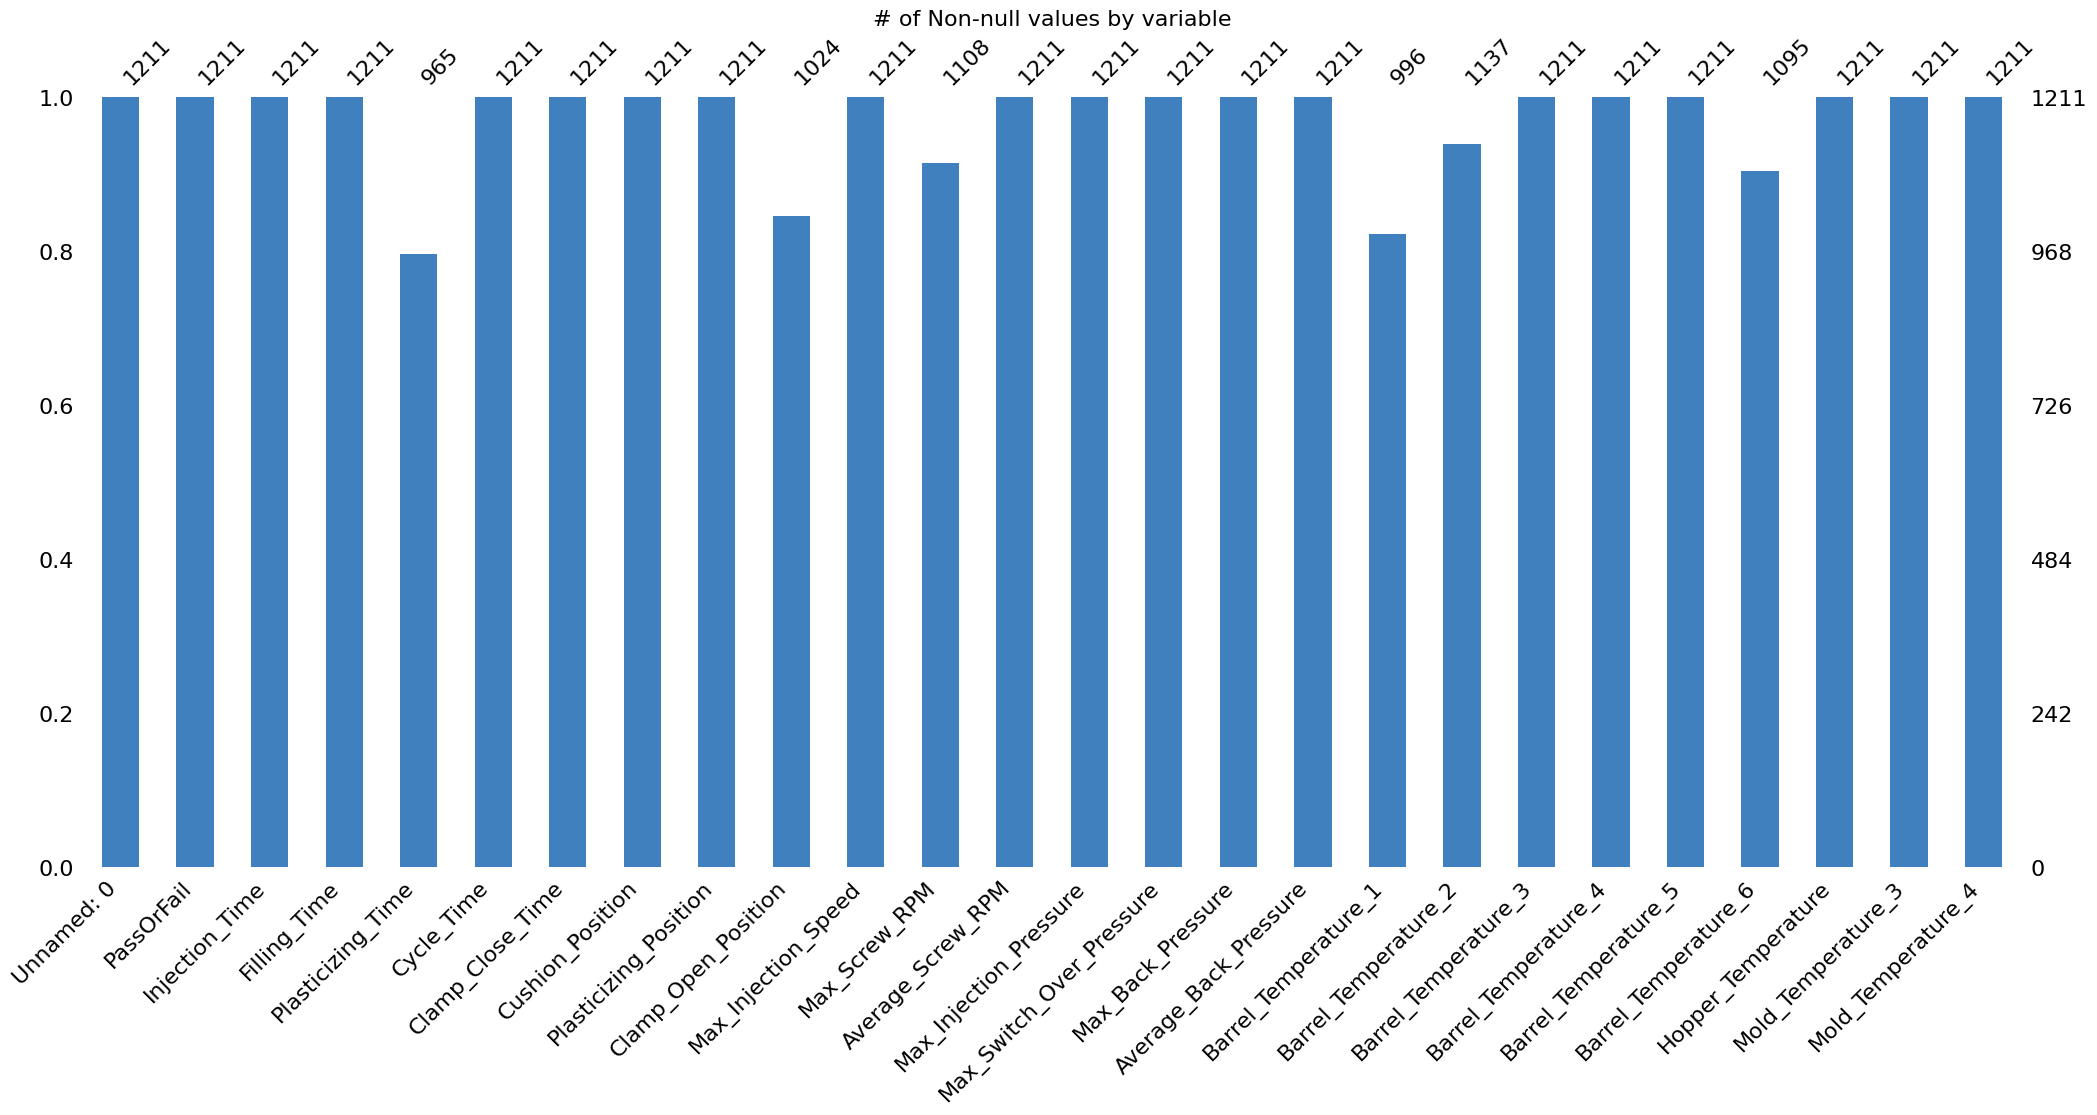

In [12]:
# msno.bar: 각 컬럼별 정상 데이터(Non-Null)의 개수를 막대그래프로 시각화
# 결측 비율이 높아서 아예 제거해야 할 컬럼을 식별하는 데 유용
plt.figure(figsize=(12, 6))
msno.bar(df, color=(0.25, 0.5, 0.75))
plt.title('# of Non-null values by variable', fontsize=16)
plt.show()

#### **4. EDA 시각화(기타)**

In [13]:
# PassOrFail 변수와의 상관계수 계산
correlation_with_target = df.corr()['PassOrFail'].sort_values(ascending=False)
print("Correlation with PassOrFail:")
print(correlation_with_target)

Correlation with PassOrFail:
PassOrFail                  1.000000
Max_Injection_Speed         0.325751
Plasticizing_Position       0.178564
Mold_Temperature_4          0.163068
Mold_Temperature_3          0.145175
Clamp_Close_Time            0.143171
Max_Switch_Over_Pressure    0.101019
Barrel_Temperature_6        0.029203
Cycle_Time                  0.014533
Barrel_Temperature_4        0.012699
Barrel_Temperature_3        0.004407
Barrel_Temperature_5       -0.022790
Average_Screw_RPM          -0.023885
Max_Screw_RPM              -0.031369
Barrel_Temperature_1       -0.035840
Plasticizing_Time          -0.047760
Barrel_Temperature_2       -0.055028
Injection_Time             -0.078447
Filling_Time               -0.079426
Hopper_Temperature         -0.079547
Max_Injection_Pressure     -0.144281
Cushion_Position           -0.151526
Average_Back_Pressure      -0.159996
Unnamed: 0                 -0.170864
Max_Back_Pressure          -0.176061
Clamp_Open_Position              NaN
Name: Pas

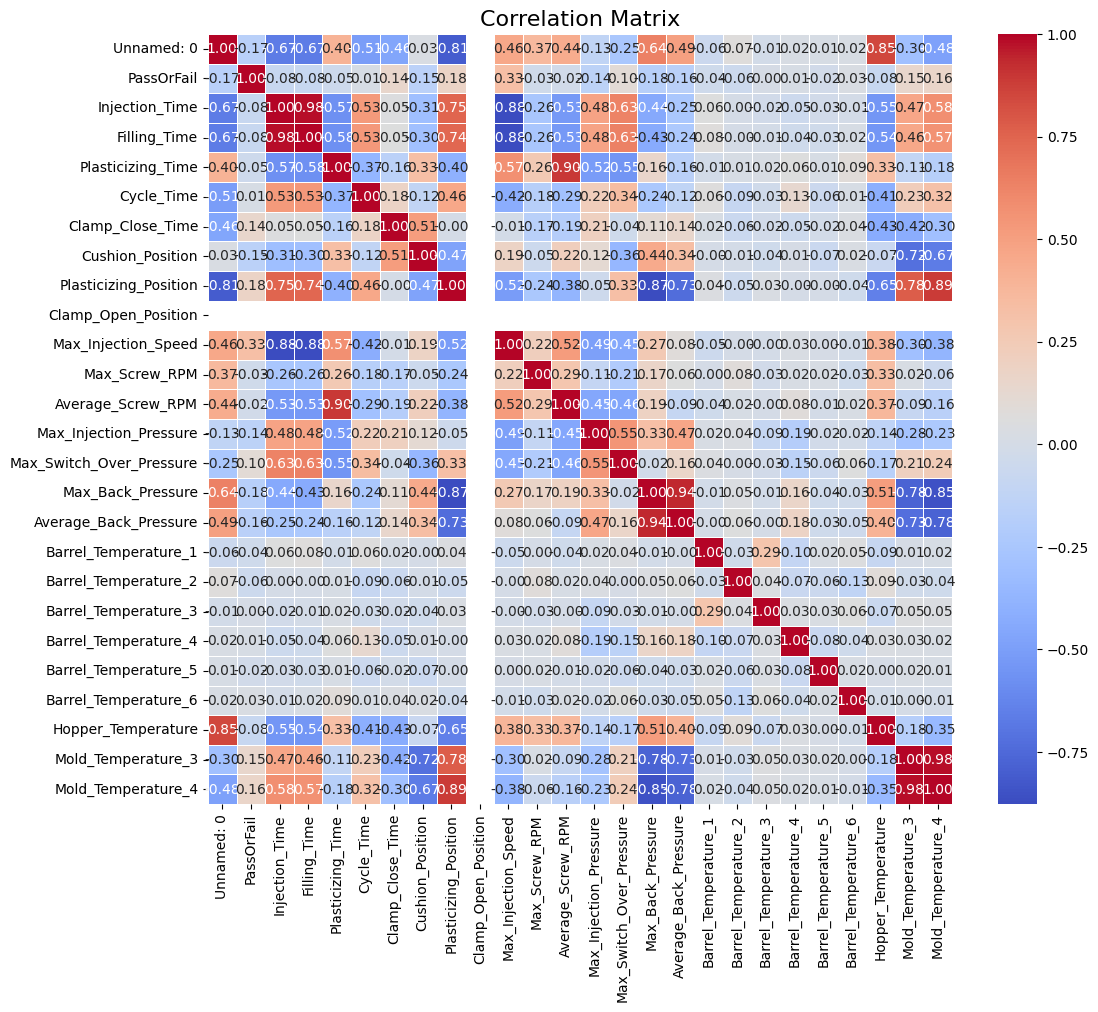

In [14]:
# 변수간 상관관계 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix', fontsize=16)
plt.show()

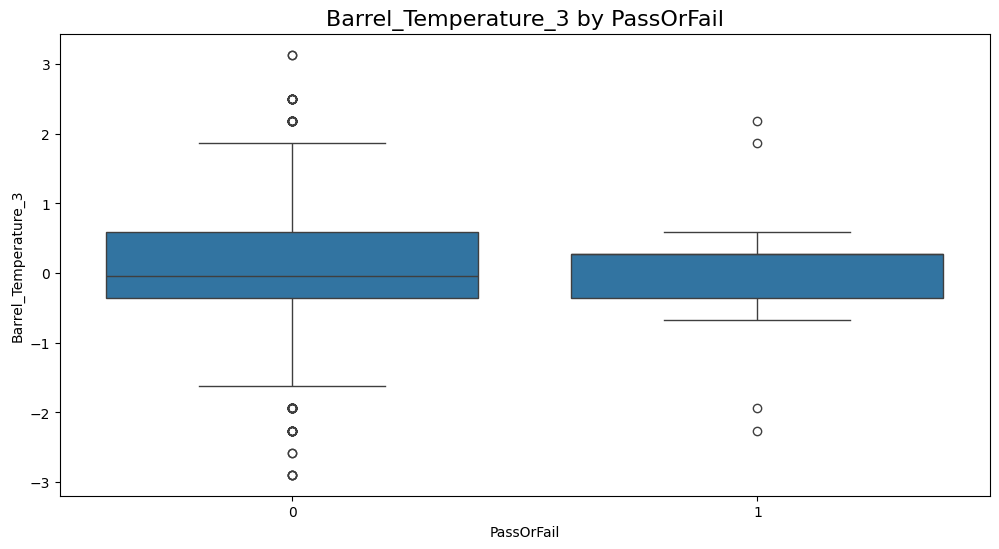

In [15]:
# 박스플롯 시각화: 양품일 때와 불량일 때의 변수 분포 비교
plt.figure(figsize=(12, 6))
sns.boxplot(x='PassOrFail', y='Barrel_Temperature_3', data=df) # y: 배럴 온도
plt.title('Barrel_Temperature_3 by PassOrFail', fontsize=16)
plt.show()


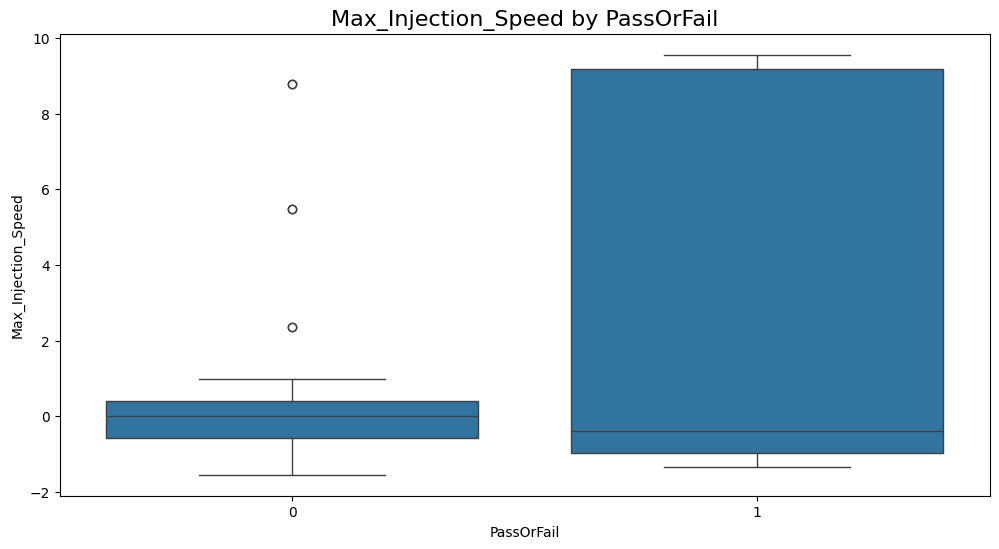

In [16]:
# 박스플롯 시각화: 양품일 때와 불량일 때의 변수 분포 비교
plt.figure(figsize=(12, 6))
sns.boxplot(x='PassOrFail', y='Max_Injection_Speed', data=df) # y: 최대사출속도
plt.title('Max_Injection_Speed by PassOrFail', fontsize=16)
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       106
           1       0.00      0.00      0.00         2

    accuracy                           0.98       108
   macro avg       0.49      0.50      0.50       108
weighted avg       0.96      0.98      0.97       108

Confusion Matrix:
[[106   0]
 [  2   0]]


/opt/anaconda3/envs/datasci260309/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/datasci260309/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/datasci260309/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

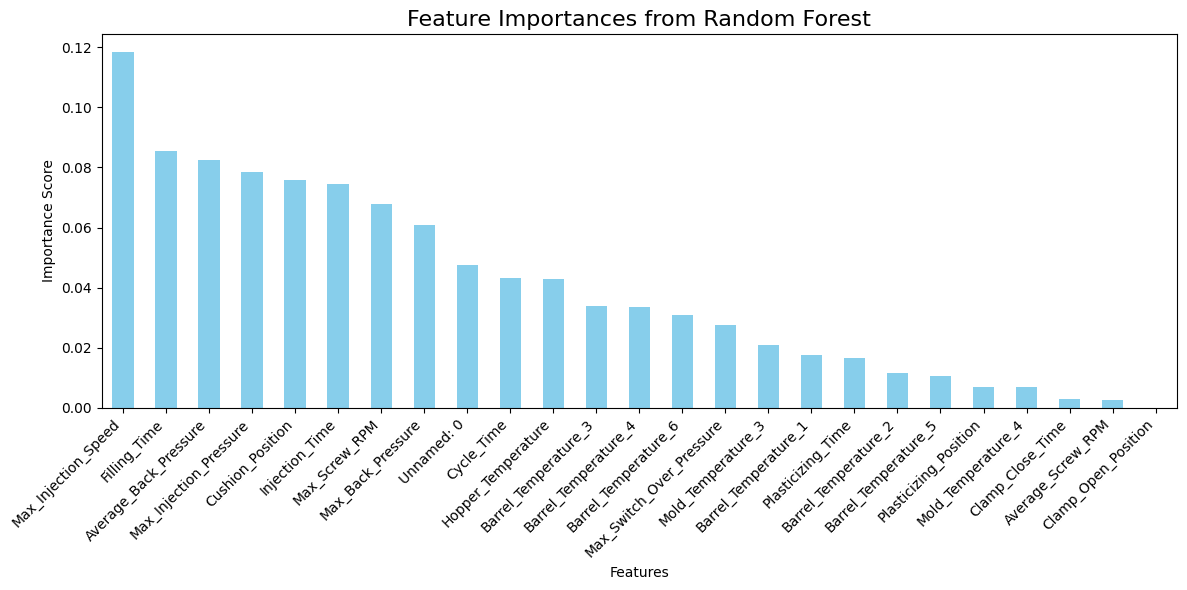

In [17]:
# Random Forest 모델을 사용하여 변수 중요도 시각화
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 데이터 전처리: 결측치 제거 및 범주형 변수 인코딩
# 결측치가 있는 행 제거 (간단한 방법)
df_clean = df.dropna()

# 특성과 타겟 변수 분리 (X: 특성, y: 타겟)
X = df_clean.drop('PassOrFail', axis=1) # 특성 데이터
y = df_clean['PassOrFail'] # 타겟 데이터

# 학습용 데이터와 테스트용 데이터로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, 
                                                    random_state=42,
                                                    stratify=y) # 클래스 불균형 고려 
# Random Forest 모델 학습
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 모델 예측
y_pred = rf_model.predict(X_test)

# 모델 평가
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 변수 중요도 시각화
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(12, 6))
feature_importances.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Feature Importances from Random Forest', fontsize=16)
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
